# 05 — Deeper evaluation

Phase 5: **no retraining**. Load the four Phase 3/4 pickles and the Phase 2 test set.

Best model for threshold / error analysis is taken from `reports/model_comparison.csv` (highest test ROC-AUC), not hardcoded.

Script: `ml/evaluate.py`. No tuning (Phase 6) and no `final_model.pkl` (Phase 7).

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "ml" / "evaluate.py").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ml.evaluate import run_evaluation

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

result = run_evaluation()
FIG = ROOT / "reports" / "figures"
print("best model:", result["best_model"])

Phase 5 complete (no retrain / no final-model pick).
  best by test ROC-AUC (from model_comparison.csv): Random Forest
  ROC-AUC {'Logistic Regression': 0.5898, 'Decision Tree': 0.5173, 'Random Forest': 0.594, 'XGBoost': 0.5892}
  AP      {'Logistic Regression': 0.5567, 'Decision Tree': 0.4835, 'Random Forest': 0.5601, 'XGBoost': 0.5571}
 threshold  precision  recall     f1  predicted_positive_rate
    0.3000     0.4758  0.9980 0.6444                   0.9954
    0.4000     0.4951  0.8964 0.6378                   0.8593
    0.5000     0.5653  0.4127 0.4771                   0.3465
    0.6000     0.6482  0.0629 0.1147                   0.0461
    0.7000     0.7843  0.0021 0.0042                   0.0013
  recommend threshold 0.4 recall-first among thresholds that flag <=90% of orders and keep precision >= 0.47 (near prevalence); 0.5 is not the default
  calibration flags {'Logistic Regression': 'well_calibrated', 'Decision Tree': 'overconfident', 'Random Forest': 'well_calibrated', 'XGB

## 1. ROC curves

All four models on one plot. AUC is in the legend. Saved as `reports/figures/07_roc_curves.png`.

{'Logistic Regression': 0.5898, 'Decision Tree': 0.5173, 'Random Forest': 0.594, 'XGBoost': 0.5892}


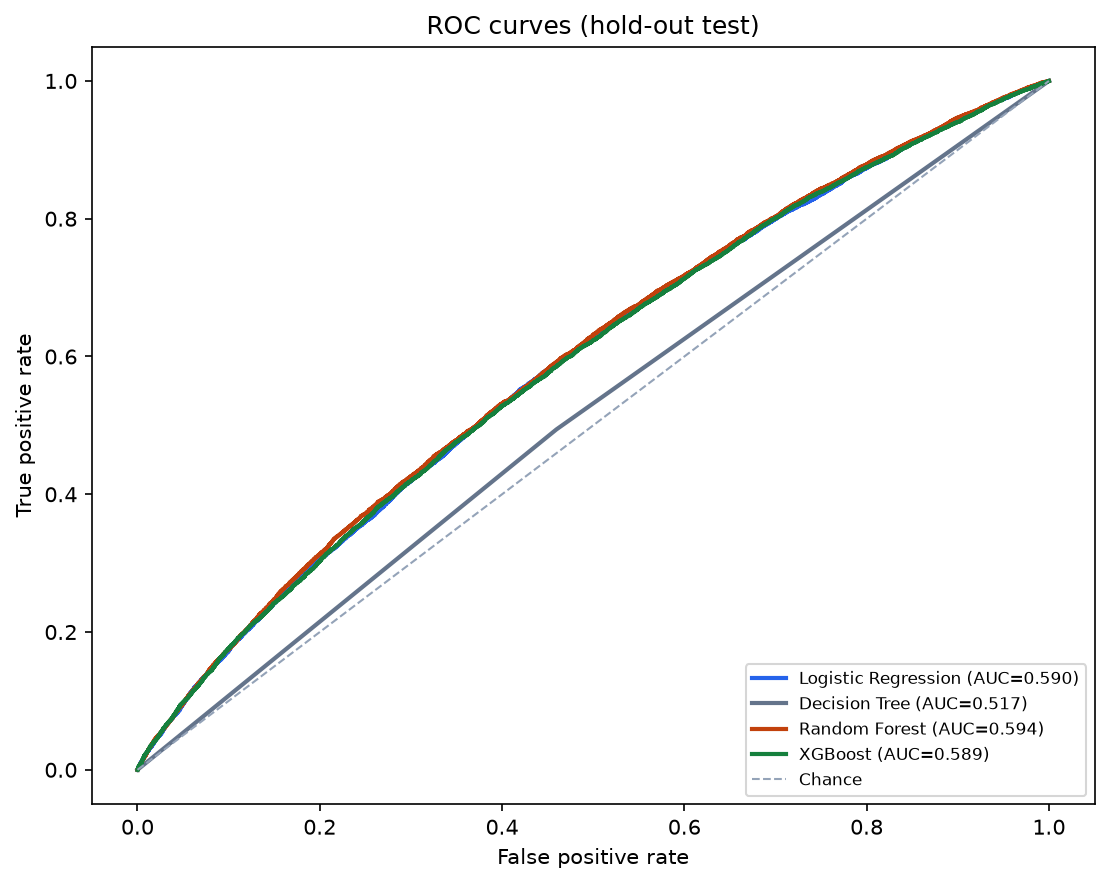

In [2]:
print({k: round(v, 4) for k, v in result["aucs"].items()})
display(Image(filename=str(FIG / "07_roc_curves.png")))

## 2. Precision–recall curves

The target is close to balanced (~47.5% / 52.5%), so ROC is not badly skewed — but **false negatives and false positives have different business costs**, so PR still matters. Horizontal dashed line = class prevalence. Saved as `reports/figures/08_pr_curves.png`.

{'Logistic Regression': 0.5567, 'Decision Tree': 0.4835, 'Random Forest': 0.5601, 'XGBoost': 0.5571}


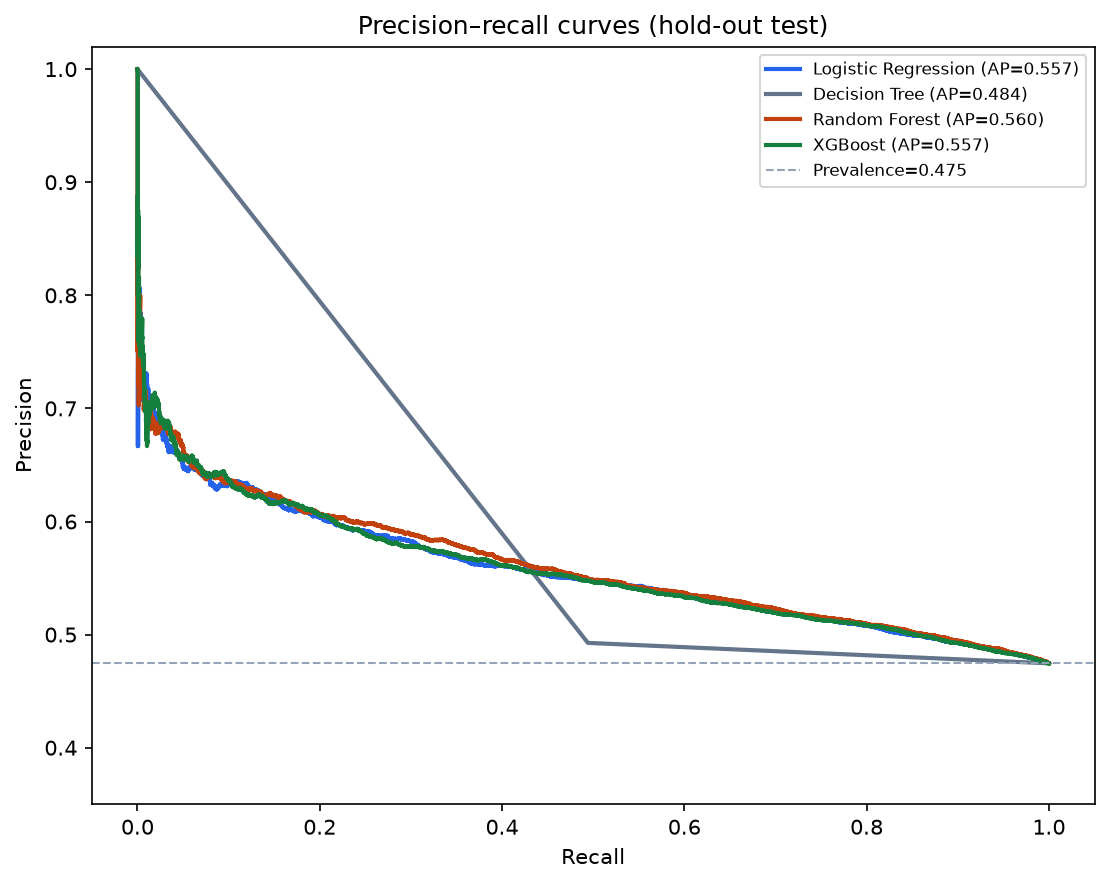

In [3]:
print({k: round(v, 4) for k, v in result["aps"].items()})
display(Image(filename=str(FIG / "08_pr_curves.png")))

## 3. Threshold analysis (best model by test ROC-AUC)

**Framing:** catching a true future return (**recall**) is more valuable than avoiding a false alarm (**precision**). The system exists to flag orders for intervention *before fulfillment*. Reverse-logistics cost of a missed return beats the review cost of an extra flag. **0.5 is not the default.**

model: Random Forest


,threshold,precision,recall,f1,predicted_positive_rate
0,0.3,0.4758,0.9980,0.6444,0.9954
1,0.4,0.4951,0.8964,0.6378,0.8594
2,0.5,0.5653,0.4127,0.4771,0.3465
3,0.6,0.6482,0.0629,0.1147,0.0460
4,0.7,0.7843,0.0021,0.0042,0.0013


{'recommended_threshold': 0.4, 'precision': 0.4950544015825915, 'recall': 0.8963864306784661, 'f1': 0.6378424978447468, 'predicted_positive_rate': 0.85935, 'rule': 'recall-first among thresholds that flag <=90% of orders and keep precision >= 0.47 (near prevalence); 0.5 is not the default', 'business_framing': 'Recall is more valuable than precision: the system should catch orders that will be returned so operations can intervene before fulfillment. False alarms cost review effort; missed returns cost reverse logistics. Threshold 0.3 flags almost every order so it is not useful. 0.4 roughly doubles recall vs 0.5 while precision stays near the base rate.'}


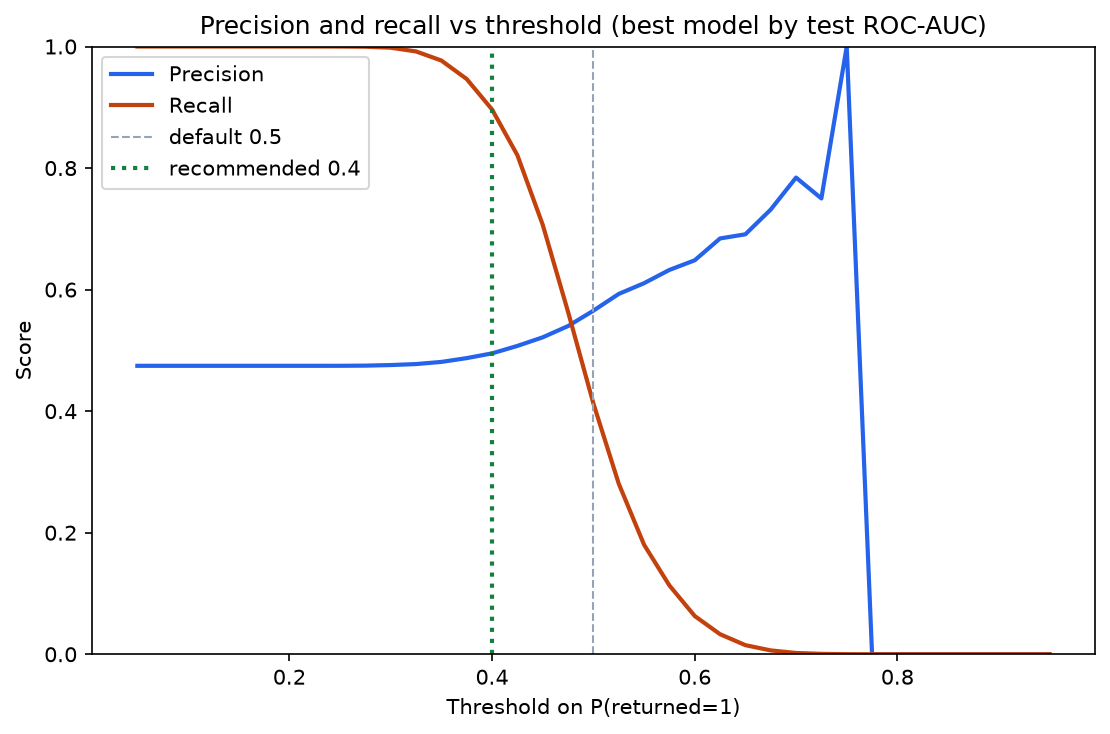

In [4]:
print("model:", result["best_model"])
display(result["threshold_table"].round(4))
print(result["recommendation"])
display(Image(filename=str(FIG / "14_threshold_precision_recall.png")))

**Recommendation: threshold 0.4** on the current Random Forest scores (not 0.5).

| Threshold | Precision | Recall | % of orders flagged | Comment |
|-----------|-----------|--------|---------------------|---------|
| 0.3 | 0.476 | 0.998 | 99.5% | Not selective — almost every order |
| **0.4** | **0.495** | **0.896** | **86%** | Recall-first; precision ≈ prevalence |
| 0.5 | 0.565 | 0.413 | 35% | Misses ~59% of true returns |
| 0.6 / 0.7 | higher precision | 0.06 / 0.00 | tiny | Useless as a catch-returns screen |

RF probabilities sit in a narrow band (~0.35–0.62), so 0.3–0.4 moves a lot of mass. 0.4 still flags a large share of volume; operations may later cap how many orders they can review. That capacity constraint is a Phase 7 product choice, not a reason to pretend 0.5 is optimal.

## 4. Calibration

,brier,ece_quantile_bins,flag,overconfident
Logistic Regression,0.243091,0.007254,well_calibrated,False
Decision Tree,0.481574,0.482752,overconfident,True
Random Forest,0.242639,0.012531,well_calibrated,False
XGBoost,0.243466,0.013504,well_calibrated,False


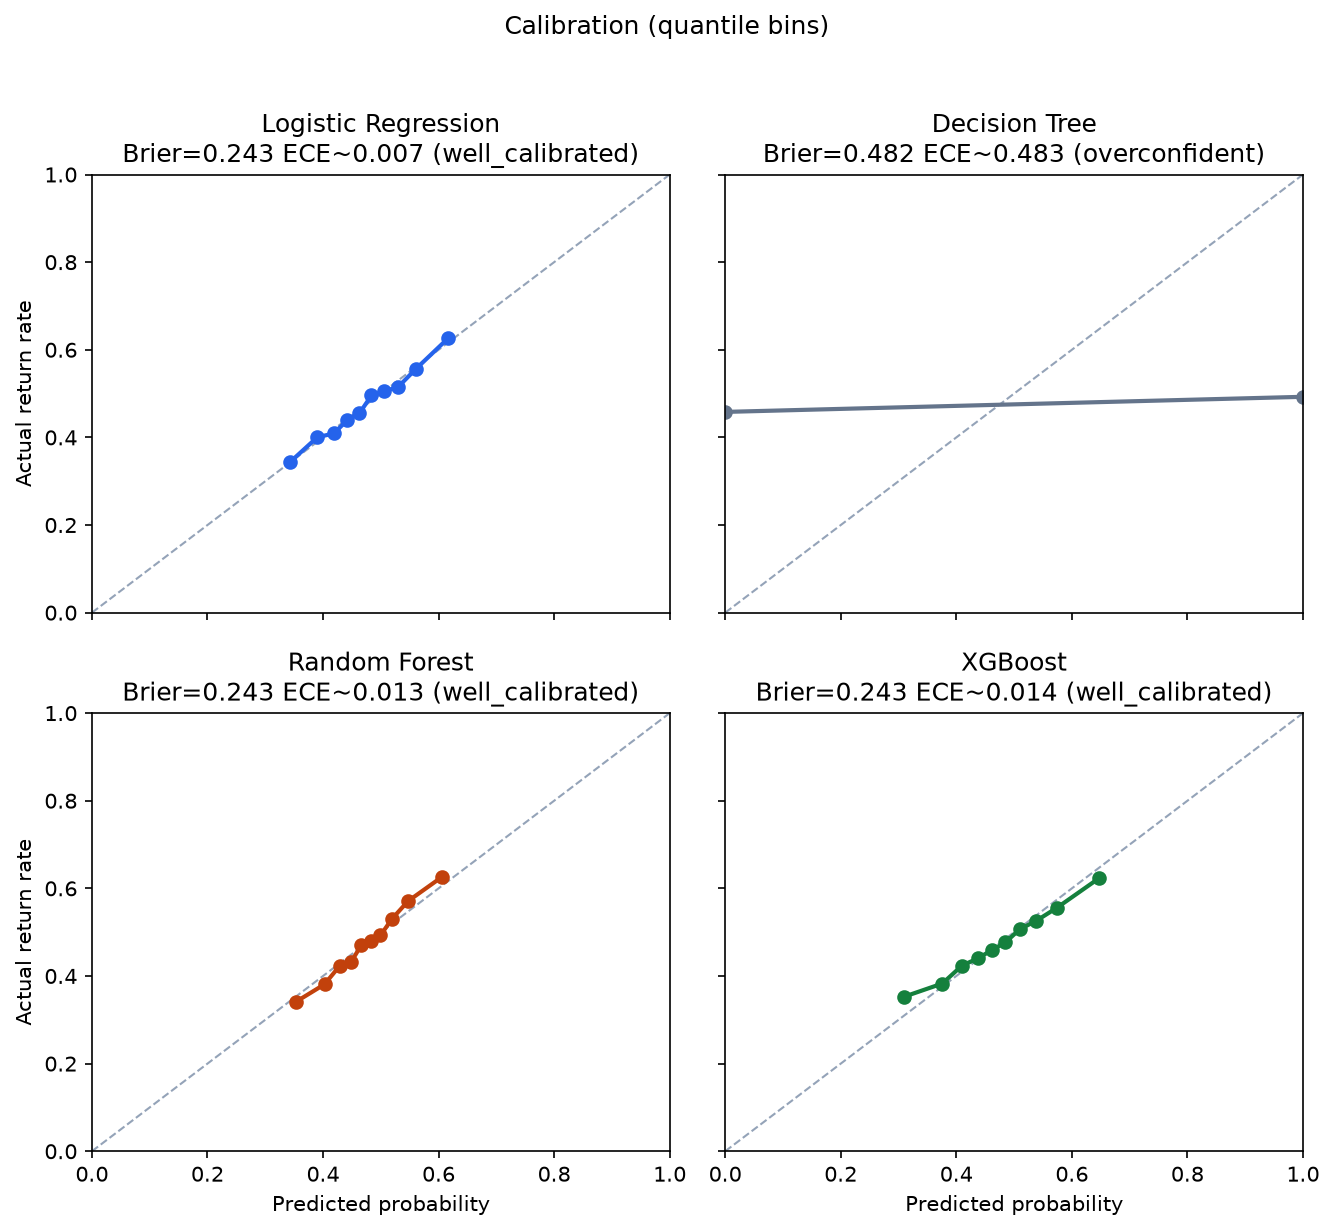

In [5]:
display(pd.DataFrame(result["calibration"]).T)
display(Image(filename=str(FIG / "13_calibration_curves.png")))

- **Logistic Regression:** best calibration (points on the diagonal, lowest ECE). Probabilities are usable as risk scores.
- **Random Forest and XGBoost:** also close to the diagonal in quantile bins (flagged well-calibrated) but **compressed** into a narrow probability range — they rank similarly to LR (AUC ~0.59) without using the full 0–1 scale.
- **Decision Tree:** strongly **overconfident** (near-0/1 scores, Brier ~0.48). Do not use its `predict_proba` as a risk percentage.

## 5. Error analysis (best model, default 0.5 for FP/FN labels)

10 false positives and 10 false negatives, plus patterns on **all** FP/FN (not only the sample). Features are from cleaned `test.csv` (original units), not the scaled matrix.

In [6]:
pat = result["errors"]["patterns"]
print("n FP", pat["n_false_positives"], "n FN", pat["n_false_negatives"])
print("FN mean price", round(pat["fn_mean_product_price"], 2), "vs all returns", round(pat["all_returns_mean_product_price"], 2))
print("FN coupon rate", round(pat["fn_coupon_rate"], 3), "vs all returns", round(pat["return_coupon_rate"], 3))
print("FP coupon rate", round(pat["fp_coupon_rate"], 3), "vs non-returns", round(pat["non_return_coupon_rate"], 3))
print("FN categories", pat["fn_vs_all_positives_category"])
print("FN shipping", pat["fn_vs_all_positives_shipping"])
print("\nFalse negatives (sample)")
display(result["errors"]["fn_sample"])
print("False positives (sample)")
display(result["errors"]["fp_sample"])

n FP 6025 n FN 11149
FN mean price 34.57 vs all returns 39.8
FN coupon rate 0.545 vs all returns 0.641
FP coupon rate 0.753 vs non-returns 0.591
FN categories {'false_negatives': {'electronics': 0.2173, 'toys': 0.2089, 'home': 0.1841, 'beauty': 0.168, 'sports': 0.1336, 'clothing': 0.0881}, 'all_returns': {'toys': 0.2528, 'beauty': 0.1927, 'electronics': 0.1568, 'home': 0.1492, 'clothing': 0.1363, 'sports': 0.1121}}
FN shipping {'false_negatives': {'standard': 0.7401, 'express': 0.1589, 'same_day': 0.101}, 'all_returns': {'standard': 0.6279, 'express': 0.3016, 'same_day': 0.0705}}

False negatives (sample)


,test_row,pred_proba,customer_age,product_price,discount_percent,product_rating,past_purchase_count,past_return_rate,delivery_delay_days,session_length_minutes,num_product_views,device_type,product_category,shipping_method,payment_method,used_coupon,returned
7145,7145,0.467802,38,18.648207,75.528729,3.377795,9,0.132622,2.629879,124.208002,16,desktop,home,standard,apple_pay,0,1
14755,14755,0.460981,56,40.200256,26.714783,2.141550,9,0.527188,1.341326,71.260671,0,tablet,clothing,standard,paypal,0,1
15999,15999,0.392214,42,7.120274,9.396367,4.187684,10,0.308197,0.946016,128.236369,36,mobile,sports,standard,apple_pay,0,1
17890,17890,0.346047,22,47.720607,57.555268,2.822055,9,0.069529,-0.205138,132.567780,4,mobile,beauty,standard,debit_card,0,1
20001,20001,0.454118,79,19.024725,53.697973,3.691065,9,0.355768,2.124408,74.338784,37,desktop,home,standard,apple_pay,0,1
21706,21706,0.452712,26,67.884704,47.307955,4.334236,11,0.155107,5.385807,131.024743,19,mobile,clothing,standard,credit_card,1,1
25802,25802,0.475618,76,84.324094,43.172098,4.669367,18,0.002299,0.700519,108.211442,1,desktop,home,standard,paypal,1,1
31296,31296,0.470437,30,20.653976,18.080210,1.011580,12,0.068301,-1.469642,13.286684,19,mobile,toys,standard,paypal,1,1
32914,32914,0.448432,61,112.381222,46.194390,2.788610,10,0.037750,1.051981,74.692249,12,mobile,beauty,standard,apple_pay,0,1
37076,37076,0.383543,69,3.412162,64.852955,4.646292,8,0.254939,0.324413,72.944655,0,mobile,electronics,standard,credit_card,1,1


False positives (sample)


,test_row,pred_proba,customer_age,product_price,discount_percent,product_rating,past_purchase_count,past_return_rate,delivery_delay_days,session_length_minutes,num_product_views,device_type,product_category,shipping_method,payment_method,used_coupon,returned
3594,3594,0.504025,55,32.611632,33.451882,1.588521,17,0.163170,-1.527666,93.521111,4,mobile,beauty,standard,apple_pay,1,0
3728,3728,0.596136,40,20.109051,70.869474,1.000000,8,0.288588,1.070447,119.533593,19,mobile,beauty,express,paypal,1,0
3981,3981,0.613230,75,28.749532,21.130014,4.495104,8,0.147184,-0.064682,42.609368,0,mobile,toys,express,credit_card,1,0
8365,8365,0.519192,40,136.308084,40.084034,1.899521,10,0.219960,-1.650781,19.915023,5,mobile,clothing,standard,credit_card,1,0
17752,17752,0.560659,79,188.582191,36.452222,1.992081,16,0.459054,-4.436076,26.139458,0,mobile,toys,express,paypal,0,0
17983,17983,0.519036,54,8.184838,47.172652,4.245753,9,0.153692,-6.602782,30.246067,12,tablet,beauty,express,credit_card,0,0
26169,26169,0.511598,39,25.325502,15.306837,4.698484,7,0.122900,3.863860,119.537673,25,desktop,home,standard,apple_pay,0,0
27852,27852,0.512625,27,48.374538,12.341539,1.279399,9,0.152095,5.724296,132.745590,31,mobile,home,express,apple_pay,1,0
31071,31071,0.529100,75,9.343704,72.811266,2.824713,9,0.683934,0.233016,74.867513,1,desktop,toys,standard,apple_pay,1,0
34509,34509,0.508189,62,0.000000,54.917525,5.000000,7,0.096040,-0.739287,88.191936,37,mobile,toys,standard,apple_pay,1,0


**Pattern:** at threshold 0.5 the Random Forest **misses returns that look “safe”** on the Phase 1/3 signals:

- False negatives over-index **electronics** and **standard** shipping, **lower price**, **lower coupon use**.
- False positives over-index **clothing / toys / beauty**, **express-like risk profile**, and **coupons**.

That is the same clothing/express/coupon story as LR and XGBoost importances: the model trusts those cues and then fails on the complementary slice. Tuning (Phase 6) will not automatically fix this without features or a recall-oriented threshold.

## 6. Summary — not a final-model pick

All four models **plateau around test ROC-AUC 0.59** (DT ~0.52 is the exception and is unusable: overfit + miscalibrated). RF is only ~0.004 AUC above LR. That gap is **not** a business-relevant win.

For **return-risk flagging** specifically:

- No model is clearly better on ranking quality alone.
- **LR** is the robustness story: train/test AUC matched, best calibration, interpretable coefficients that match EDA.
- **RF / XGBoost** have **tuning headroom** (they still overfit by the Phase 4 0.05 gap rule) and XGB already agrees with the category/coupon signal.
- Operating **threshold** (0.4 vs 0.5) moves recall more than swapping RF for LR at 0.5.

**Phase 6/7 should not be decided by raw ROC-AUC.** Tune RF/XGB against overfit and a recall-oriented metric/threshold; keep LR as the calibrated baseline. A production winner is Phase 7, after that work.